In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt

from mne.datasets import eegbci

In [3]:
subject = 1
runs = [4, 8, 12]

files = eegbci.load_data(subject, runs)

print(files)

[WindowsPath('C:/Users/diopi/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf'), WindowsPath('C:/Users/diopi/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf'), WindowsPath('C:/Users/diopi/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf')]


In [4]:
raw = mne.io.read_raw_edf(files[0], preload=True)

print(raw)
print(raw.info)

Extracting EDF parameters from C:\Users\diopi\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R04.edf...


Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


In [5]:
data = raw.get_data()

print(data.shape)

print(raw.ch_names)

(64, 20000)
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


In [6]:
eegbci.standardize(raw)

print(raw.ch_names)

['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz']


In [7]:
montage = mne.channels.make_standard_montage("standard_1005")
raw.set_montage(montage)
print(raw.get_montage())

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 64 channels>


In [8]:
print(raw.annotations)

<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>


In [9]:
events, event_id = mne.events_from_annotations(raw)

print(event_id)
print(events[:10])

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]


Using matplotlib as 2D backend.


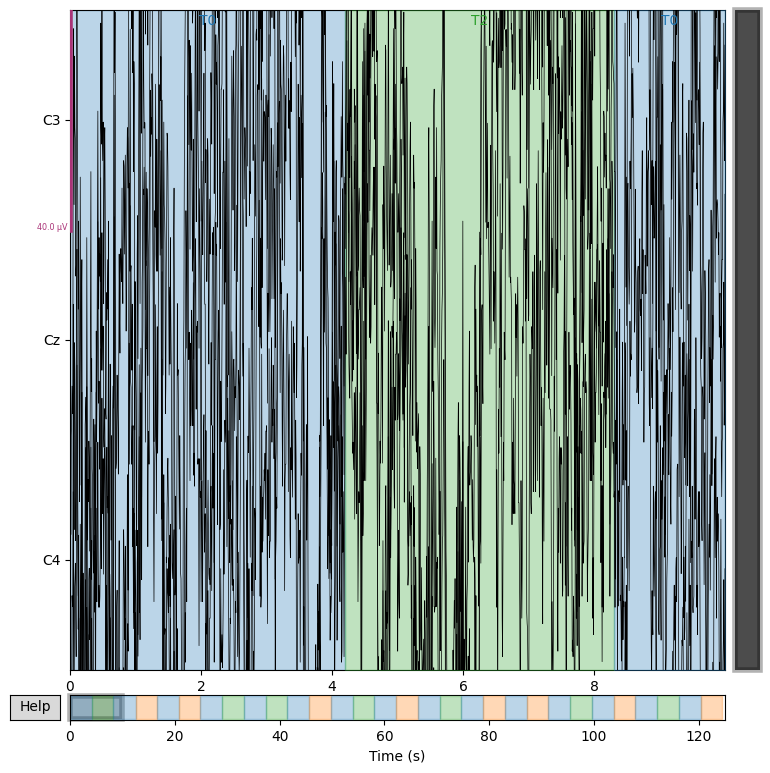

In [10]:
browser = raw.plot(
    duration=10,
    picks=["C3", "Cz", "C4"]
)

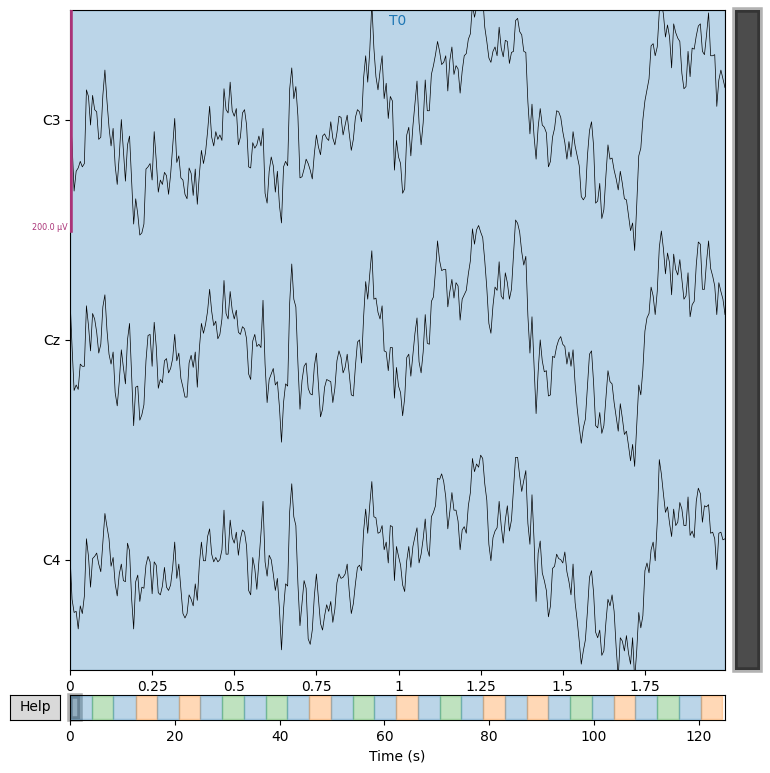

In [11]:
browser = raw.plot(
    duration=2,
    picks=["C3", "Cz", "C4"],
    scalings={"eeg": 100e-6}
)

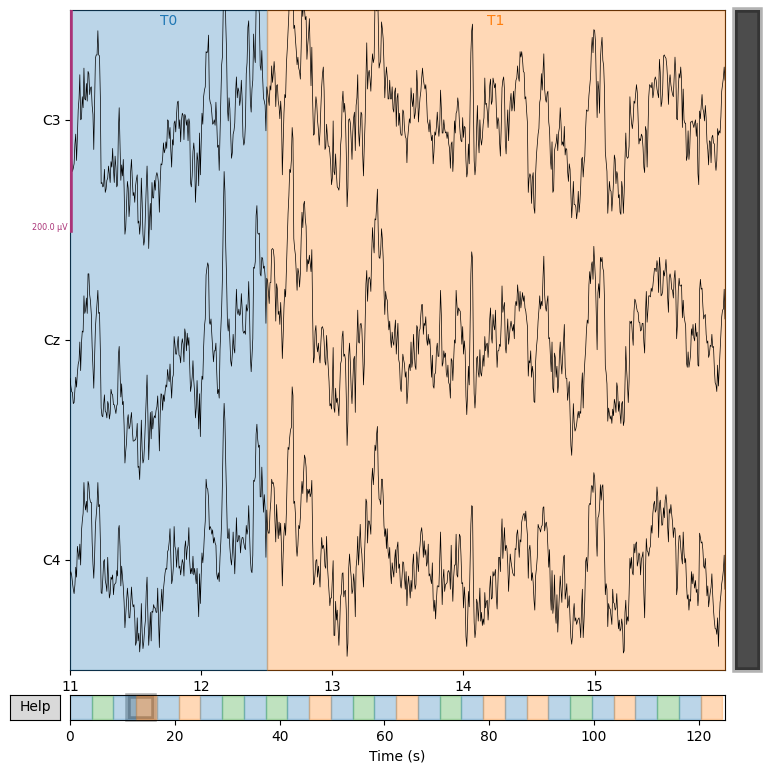

In [12]:
browser = raw.plot(
    start=11,
    duration=5,
    picks=["C3", "Cz", "C4"],
    scalings={"eeg": 100e-6}
)

In [13]:
for i in range(6):
    print(
        raw.annotations.description[i],
        "starts at", raw.annotations.onset[i], "s,",
        "duration =", raw.annotations.duration[i], "s"
    )

T0 starts at 0.0 s, duration = 4.2 s
T2 starts at 4.2 s, duration = 4.1 s
T0 starts at 8.3 s, duration = 4.2 s
T1 starts at 12.5 s, duration = 4.1 s
T0 starts at 16.6 s, duration = 4.2 s
T1 starts at 20.8 s, duration = 4.1 s


In [14]:
motor_event_id = {
    "left": event_id["T1"],
    "right": event_id["T2"]
}

print(motor_event_id)

{'left': 2, 'right': 3}


In [15]:
epochs = mne.Epochs(
    raw,
    events,
    event_id=motor_event_id,
    tmin=0,
    tmax=4.0,
    baseline=None,
    preload=True
)

print(epochs)

Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 641 original time points ...
0 bad epochs dropped
<Epochs | 15 events (all good), 0 – 4 s (baseline off), ~4.8 MiB, data loaded,
 'left': 8
 'right': 7>


In [16]:
X = epochs.get_data()

print(X.shape)

(15, 64, 641)


In [17]:
y = epochs.events[:, 2]

print(y)
print(y.shape)

[3 2 2 3 3 2 3 2 3 2 2 3 2 3 2]
(15,)


In [18]:
y_binary = np.where(y == 2, 0, 1)

print(y_binary)

[1 0 0 1 1 0 1 0 1 0 0 1 0 1 0]


Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


c:\Users\diopi\eeg-motor-imagery\.venv\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


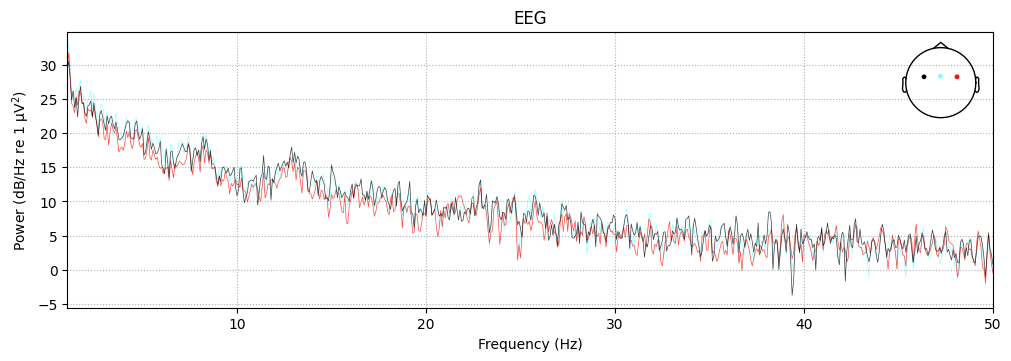

In [19]:
psd = raw.compute_psd(
    fmin=1,
    fmax=50,
    picks=["C3", "Cz", "C4"]
)

psd.plot()

In [20]:
epoch_psd = epochs.compute_psd(
    fmin=1,
    fmax=40,
    picks=["C3", "C4"]
)

psd_data, freqs = epoch_psd.get_data(return_freqs=True)

print(psd_data.shape)
print(freqs.shape)

    Using multitaper spectrum estimation with 7 DPSS windows
(15, 2, 156)
(156,)


In [21]:
left_psd = psd_data[y_binary == 0]
right_psd = psd_data[y_binary == 1]

print(left_psd.shape)
print(right_psd.shape)

(8, 2, 156)
(7, 2, 156)


In [22]:
left_mean_psd = left_psd.mean(axis=0)
right_mean_psd = right_psd.mean(axis=0)

print(left_mean_psd.shape)
print(right_mean_psd.shape)

(2, 156)
(2, 156)


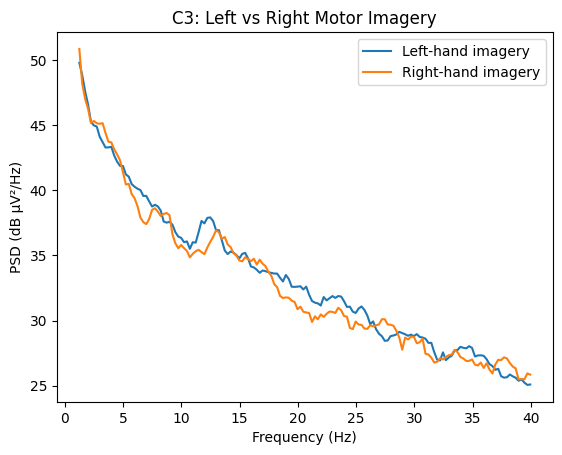

In [25]:
left_c3_db = 10 * np.log10(left_mean_psd[0] * 1e12)
right_c3_db = 10 * np.log10(right_mean_psd[0] * 1e12)

plt.figure()

plt.plot(freqs, left_c3_db, label="Left-hand imagery")
plt.plot(freqs, right_c3_db, label="Right-hand imagery")

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB µV²/Hz)")
plt.title("C3: Left vs Right Motor Imagery")
plt.legend()

plt.show()

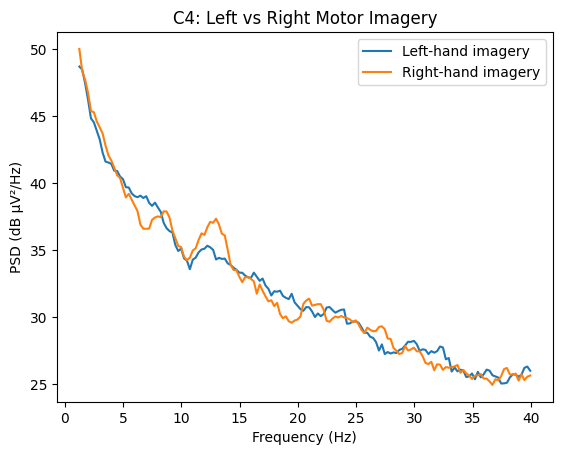

In [26]:
left_c4_db = 10 * np.log10(left_mean_psd[1] * 1e12)
right_c4_db = 10 * np.log10(right_mean_psd[1] * 1e12)

plt.figure()

plt.plot(freqs, left_c4_db, label="Left-hand imagery")
plt.plot(freqs, right_c4_db, label="Right-hand imagery")

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB µV²/Hz)")
plt.title("C4: Left vs Right Motor Imagery")
plt.legend()

plt.show()

In [27]:
mu_mask = (freqs >= 8) & (freqs <= 13)

mu_power = np.trapezoid(
    psd_data[:, :, mu_mask],
    freqs[mu_mask],
    axis=2
)

print(mu_power.shape)
print(mu_power)

(15, 2)
[[1.91672684e-08 1.84657416e-08]
 [1.65478885e-08 1.34044676e-08]
 [2.25870397e-08 1.35119995e-08]
 [1.61187977e-08 1.59185165e-08]
 [1.52778876e-08 1.72186121e-08]
 [2.15744081e-08 1.20442437e-08]
 [2.26789750e-08 2.75653458e-08]
 [2.35921621e-08 2.08312225e-08]
 [2.61789141e-08 1.69316549e-08]
 [2.63697638e-08 1.88813758e-08]
 [2.13452211e-08 1.50445444e-08]
 [2.25872614e-08 1.60380480e-08]
 [2.01688234e-08 1.24587173e-08]
 [1.79108509e-08 2.74966018e-08]
 [3.91600157e-08 2.35555637e-08]]


In [28]:
mu_power_db = 10 * np.log10(mu_power * 1e12)

print(mu_power_db.shape)
print(mu_power_db)

(15, 2)
[[42.82560223 42.66366753]
 [42.18742585 41.27249568]
 [43.53859315 41.3071962 ]
 [42.07332644 42.01902593]
 [41.84063311 42.35998143]
 [43.3393889  40.80779535]
 [43.55623423 44.40363446]
 [43.72767744 43.18714758]
 [44.17951628 42.28699407]
 [44.2110624  42.76033635]
 [43.29300657 41.77379041]
 [43.53863578 42.05151509]
 [43.04680564 40.95473331]
 [42.53116218 44.39279025]
 [45.92842857 43.72093502]]


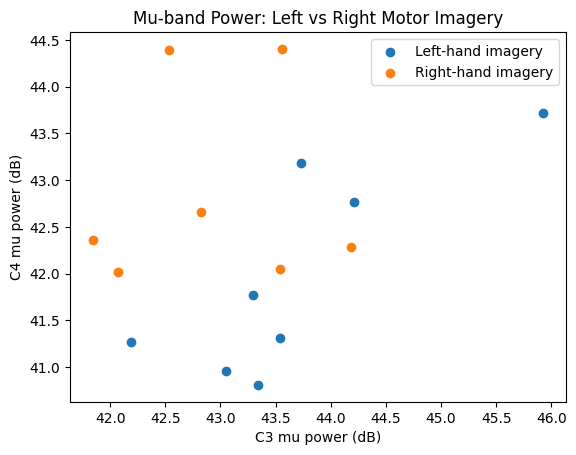

In [29]:
plt.figure()

plt.scatter(
    mu_power_db[y_binary == 0, 0],
    mu_power_db[y_binary == 0, 1],
    label="Left-hand imagery"
)

plt.scatter(
    mu_power_db[y_binary == 1, 0],
    mu_power_db[y_binary == 1, 1],
    label="Right-hand imagery"
)

plt.xlabel("C3 mu power (dB)")
plt.ylabel("C4 mu power (dB)")
plt.title("Mu-band Power: Left vs Right Motor Imagery")
plt.legend()

plt.show()

In [30]:
X_features = mu_power_db
y_labels = y_binary

print(X_features.shape)
print(y_labels.shape)

(15, 2)
(15,)


In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_features, y_labels)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [[-0.87194123  0.88832518]]
Intercept: [-0.00219938]


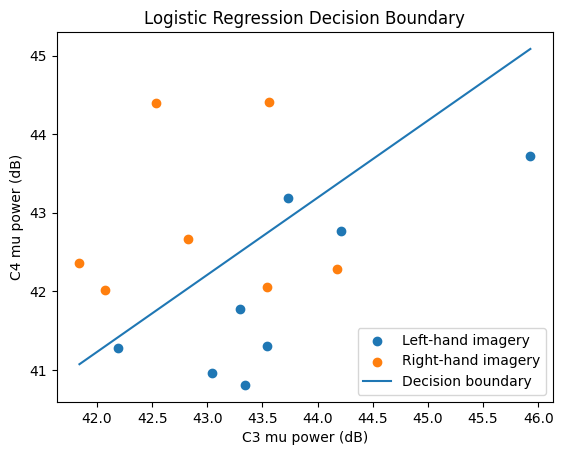

In [32]:
plt.figure()

plt.scatter(
    X_features[y_labels == 0, 0],
    X_features[y_labels == 0, 1],
    label="Left-hand imagery"
)

plt.scatter(
    X_features[y_labels == 1, 0],
    X_features[y_labels == 1, 1],
    label="Right-hand imagery"
)

w1, w2 = model.coef_[0]
b = model.intercept_[0]

x_values = np.linspace(X_features[:, 0].min(), X_features[:, 0].max(), 100)

y_boundary = -(w1 * x_values + b) / w2

plt.plot(x_values, y_boundary, label="Decision boundary")

plt.xlabel("C3 mu power (dB)")
plt.ylabel("C4 mu power (dB)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()

plt.show()

In [38]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    LogisticRegression(),
    X_features,
    y_labels,
    cv=cv,
    scoring="accuracy"
)

print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())

Fold accuracies: [1.         0.66666667 0.66666667 1.         0.66666667]
Mean accuracy: 0.7999999999999999


In [41]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(
    LogisticRegression(),
    X_features,
    y_labels,
    cv=cv
)

print("True labels:     ", y_labels)
print("Predicted labels:", y_pred)

misclassified = np.where(y_pred != y_labels)[0]

print("Misclassified trials:", misclassified)

True labels:      [1 0 0 1 1 0 1 0 1 0 0 1 0 1 0]
Predicted labels: [1 0 0 1 1 0 1 1 0 0 0 0 0 1 0]
Misclassified trials: [ 7  8 11]


In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_labels, y_pred)

print(cm)

[[7 1]
 [2 5]]


In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_labels,
        y_pred,
        target_names=["Left", "Right"]
    )
)

              precision    recall  f1-score   support

        Left       0.78      0.88      0.82         8
       Right       0.83      0.71      0.77         7

    accuracy                           0.80        15
   macro avg       0.81      0.79      0.80        15
weighted avg       0.80      0.80      0.80        15



In [44]:
raws = []

for file in files:
    run_raw = mne.io.read_raw_edf(file, preload=True)
    eegbci.standardize(run_raw)
    run_raw.set_montage(montage)
    raws.append(run_raw)

print(len(raws))

for i, run_raw in enumerate(raws):
    print(i, run_raw)

Extracting EDF parameters from C:\Users\diopi\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\diopi\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\diopi\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
3
0 <RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.9 MiB, data loaded>
1 <RawEDF | S001R08.edf, 64 x 20000 (125.0 s), ~9.9 MiB, data loaded>
2 <RawEDF | S001R12.edf, 64 x 20000 (125.0 s), ~9.9 MiB, data loaded>


In [45]:
combined_raw = mne.concatenate_raws(raws)

print(combined_raw)
print("Duration:", combined_raw.times[-1], "s")
print(combined_raw.annotations)

<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>
Duration: 374.99375 s
<Annotations | 94 segments: BAD boundary (2), EDGE boundary (2), T0 (45), ...>


In [46]:
combined_events, combined_event_id = mne.events_from_annotations(combined_raw)

print(combined_event_id)

for label, code in combined_event_id.items():
    count = np.sum(combined_events[:, 2] == code)
    print(label, ":", count)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
T0 : 45
T1 : 23
T2 : 22


In [47]:
combined_motor_event_id = {
    "left": combined_event_id["T1"],
    "right": combined_event_id["T2"]
}

combined_epochs = mne.Epochs(
    combined_raw,
    combined_events,
    event_id=combined_motor_event_id,
    tmin=0,
    tmax=4.0,
    baseline=None,
    preload=True
)

print(combined_epochs)

Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 45 events and 641 original time points ...
0 bad epochs dropped
<Epochs | 45 events (all good), 0 – 4 s (baseline off), ~14.2 MiB, data loaded,
 'left': 23
 'right': 22>


In [48]:
combined_psd = combined_epochs.compute_psd(
    fmin=1,
    fmax=40,
    picks=["C3", "C4"]
)

combined_psd_data, combined_freqs = combined_psd.get_data(return_freqs=True)

combined_y = combined_epochs.events[:, 2]
combined_y_binary = np.where(
    combined_y == combined_motor_event_id["left"],
    0,
    1
)

print("PSD shape:", combined_psd_data.shape)
print("Labels shape:", combined_y_binary.shape)
print("Left:", np.sum(combined_y_binary == 0))
print("Right:", np.sum(combined_y_binary == 1))

    Using multitaper spectrum estimation with 7 DPSS windows
PSD shape: (45, 2, 156)
Labels shape: (45,)
Left: 23
Right: 22


In [49]:
combined_mu_mask = (combined_freqs >= 8) & (combined_freqs <= 13)

combined_mu_power = np.trapezoid(
    combined_psd_data[:, :, combined_mu_mask],
    combined_freqs[combined_mu_mask],
    axis=2
)

combined_mu_power_db = 10 * np.log10(combined_mu_power * 1e12)

print(combined_mu_power_db.shape)
print(combined_mu_power_db[:5])

(45, 2)
[[42.82560223 42.66366753]
 [42.18742585 41.27249568]
 [43.53859315 41.3071962 ]
 [42.07332644 42.01902593]
 [41.84063311 42.35998143]]


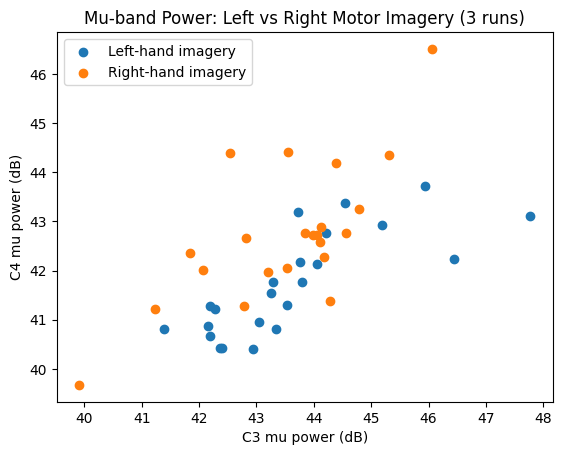

In [50]:
plt.figure()

plt.scatter(
    combined_mu_power_db[combined_y_binary == 0, 0],
    combined_mu_power_db[combined_y_binary == 0, 1],
    label="Left-hand imagery"
)

plt.scatter(
    combined_mu_power_db[combined_y_binary == 1, 0],
    combined_mu_power_db[combined_y_binary == 1, 1],
    label="Right-hand imagery"
)

plt.xlabel("C3 mu power (dB)")
plt.ylabel("C4 mu power (dB)")
plt.title("Mu-band Power: Left vs Right Motor Imagery (3 runs)")
plt.legend()

plt.show()

In [51]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

combined_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

combined_scores = cross_val_score(
    LogisticRegression(),
    combined_mu_power_db,
    combined_y_binary,
    cv=combined_cv,
    scoring="accuracy"
)

print("Fold accuracies:", combined_scores)
print("Mean accuracy:", combined_scores.mean())

Fold accuracies: [0.77777778 0.66666667 0.66666667 0.77777778 0.77777778]
Mean accuracy: 0.7333333333333333


In [52]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

combined_y_pred = cross_val_predict(
    LogisticRegression(),
    combined_mu_power_db,
    combined_y_binary,
    cv=combined_cv
)

combined_cm = confusion_matrix(
    combined_y_binary,
    combined_y_pred
)

print(combined_cm)

[[18  5]
 [ 7 15]]


In [53]:
combined_beta_mask = (combined_freqs >= 13) & (combined_freqs <= 30)

combined_beta_power = np.trapezoid(
    combined_psd_data[:, :, combined_beta_mask],
    combined_freqs[combined_beta_mask],
    axis=2
)

combined_beta_power_db = 10 * np.log10(combined_beta_power * 1e12)

print(combined_beta_power_db.shape)
print(combined_beta_power_db[:5])

(45, 2)
[[44.09415301 43.3723326 ]
 [43.49822174 42.40325552]
 [44.0146519  42.9547828 ]
 [42.88648103 42.34395821]
 [43.718909   42.72952557]]


In [54]:
combined_features_4 = np.column_stack(
    (combined_mu_power_db, combined_beta_power_db)
)

print(combined_features_4.shape)
print(combined_features_4[:5])

(45, 4)
[[42.82560223 42.66366753 44.09415301 43.3723326 ]
 [42.18742585 41.27249568 43.49822174 42.40325552]
 [43.53859315 41.3071962  44.0146519  42.9547828 ]
 [42.07332644 42.01902593 42.88648103 42.34395821]
 [41.84063311 42.35998143 43.718909   42.72952557]]


In [55]:
scores_4_features = cross_val_score(
    LogisticRegression(),
    combined_features_4,
    combined_y_binary,
    cv=combined_cv,
    scoring="accuracy"
)

print("Fold accuracies:", scores_4_features)
print("Mean accuracy:", scores_4_features.mean())

Fold accuracies: [0.55555556 0.66666667 0.66666667 0.66666667 0.77777778]
Mean accuracy: 0.6666666666666666


In [56]:
beta_only_scores = cross_val_score(
    LogisticRegression(),
    combined_beta_power_db,
    combined_y_binary,
    cv=combined_cv,
    scoring="accuracy"
)

print("Beta-only fold accuracies:", beta_only_scores)
print("Beta-only mean accuracy:", beta_only_scores.mean())

Beta-only fold accuracies: [0.55555556 0.22222222 0.66666667 0.44444444 0.44444444]
Beta-only mean accuracy: 0.4666666666666666


In [57]:
mu_difference = (
    combined_mu_power_db[:, 1]
    - combined_mu_power_db[:, 0]
).reshape(-1, 1)

print(mu_difference.shape)
print(mu_difference[:5])

(45, 1)
[[-0.1619347 ]
 [-0.91493017]
 [-2.23139694]
 [-0.05430051]
 [ 0.51934831]]


In [58]:
mu_diff_scores = cross_val_score(
    LogisticRegression(),
    mu_difference,
    combined_y_binary,
    cv=combined_cv,
    scoring="accuracy"
)

print("Mu-difference fold accuracies:", mu_diff_scores)
print("Mu-difference mean accuracy:", mu_diff_scores.mean())

Mu-difference fold accuracies: [0.77777778 0.66666667 0.77777778 0.55555556 0.77777778]
Mu-difference mean accuracy: 0.711111111111111


In [62]:
filtered_epochs = combined_epochs.copy().filter(
    l_freq=8,
    h_freq=30
)

print(filtered_epochs)

Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



<Epochs | 45 events (all good), 0 – 4 s (baseline off), ~14.2 MiB, data loaded,
 'left': 23
 'right': 22>


In [63]:
filtered_raw = combined_raw.copy().filter(
    l_freq=8,
    h_freq=30
)

csp_epochs = mne.Epochs(
    filtered_raw,
    combined_events,
    event_id=combined_motor_event_id,
    tmin=0,
    tmax=4.0,
    baseline=None,
    preload=True
)

X_csp = csp_epochs.get_data()

print(X_csp.shape)

Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 45 events and 641 original time points ...
0 bad epochs dropped
(45, 64, 641)


In [64]:
from mne.decoding import CSP
from sklearn.pipeline import make_pipeline

csp = CSP(
    n_components=4,
    reg="ledoit_wolf",
    log=True,
    norm_trace=False
)

csp_model = make_pipeline(
    csp,
    LogisticRegression(max_iter=1000)
)

csp_scores = cross_val_score(
    csp_model,
    X_csp,
    combined_y_binary,
    cv=combined_cv,
    scoring="accuracy"
)

print("CSP fold accuracies:", csp_scores)
print("CSP mean accuracy:", csp_scores.mean())

Computing rank from data with rank=None
    Using tolerance 0.00027 (2.2e-16 eps * 64 dim * 1.9e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00027 (2.2e-16 eps * 64 dim * 1.9e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00027 (2.2e-16 eps * 64 dim * 1.9e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance u

In [65]:
csp_y_pred = cross_val_predict(
    csp_model,
    X_csp,
    combined_y_binary,
    cv=combined_cv
)

csp_cm = confusion_matrix(
    combined_y_binary,
    csp_y_pred
)

print(csp_cm)

Computing rank from data with rank=None
    Using tolerance 0.00027 (2.2e-16 eps * 64 dim * 1.9e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00027 (2.2e-16 eps * 64 dim * 1.9e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00027 (2.2e-16 eps * 64 dim * 1.9e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance u

Computing rank from data with rank=None


    Using tolerance 0.0003 (2.2e-16 eps * 64 dim * 2.1e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


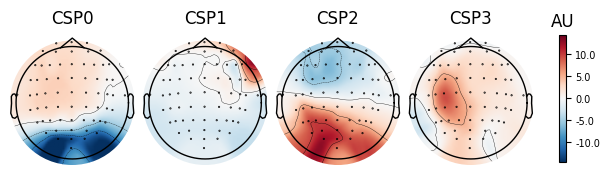

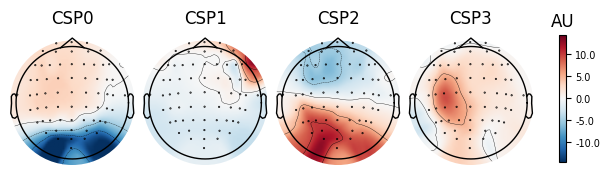

In [69]:
csp_visual = CSP(
    n_components=4,
    reg="ledoit_wolf",
    log=True,
    norm_trace=False
)

csp_visual.fit(X_csp, combined_y_binary)

csp_visual.plot_patterns(
    csp_epochs.info,
    components=[0, 1, 2, 3],
    ch_type="eeg"
)


In [70]:
from sklearn.metrics import classification_report

print(
    classification_report(
        combined_y_binary,
        csp_y_pred,
        target_names=["Left", "Right"]
    )
)

              precision    recall  f1-score   support

        Left       0.76      0.83      0.79        23
       Right       0.80      0.73      0.76        22

    accuracy                           0.78        45
   macro avg       0.78      0.78      0.78        45
weighted avg       0.78      0.78      0.78        45



In [71]:
import pandas as pd

results = pd.DataFrame({
    "Method": [
        "C3/C4 mu power",
        "C4 - C3 mu difference",
        "C3/C4 beta power",
        "Mu + beta power",
        "CSP + Logistic Regression"
    ],
    "Mean CV Accuracy": [
        combined_scores.mean(),
        mu_diff_scores.mean(),
        beta_only_scores.mean(),
        scores_4_features.mean(),
        csp_scores.mean()
    ]
})

results["Mean CV Accuracy (%)"] = (
    100 * results["Mean CV Accuracy"]
).round(1)

print(results[["Method", "Mean CV Accuracy (%)"]])

                      Method  Mean CV Accuracy (%)
0             C3/C4 mu power                  73.3
1      C4 - C3 mu difference                  71.1
2           C3/C4 beta power                  46.7
3            Mu + beta power                  66.7
4  CSP + Logistic Regression                  77.8


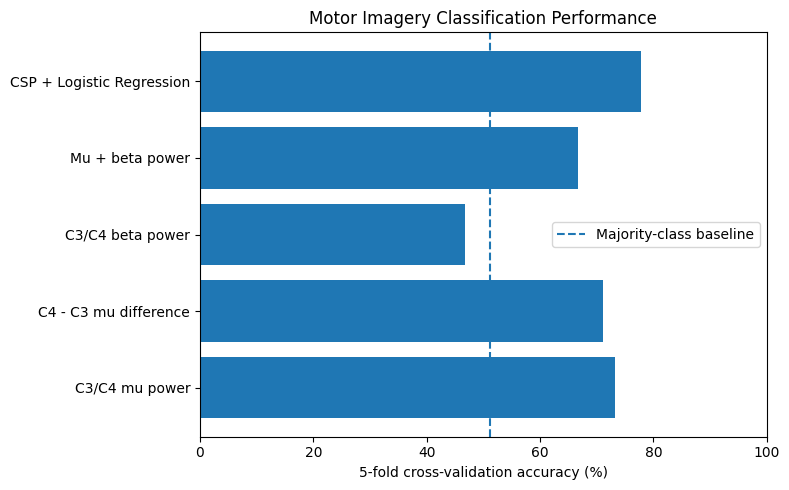

In [72]:
plt.figure(figsize=(8, 5))

plt.barh(
    results["Method"],
    results["Mean CV Accuracy (%)"]
)

plt.axvline(
    23 / 45 * 100,
    linestyle="--",
    label="Majority-class baseline"
)

plt.xlabel("5-fold cross-validation accuracy (%)")
plt.title("Motor Imagery Classification Performance")
plt.xlim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

In [73]:
from pathlib import Path

print(Path.cwd())

c:\Users\diopi\eeg-motor-imagery\notebooks


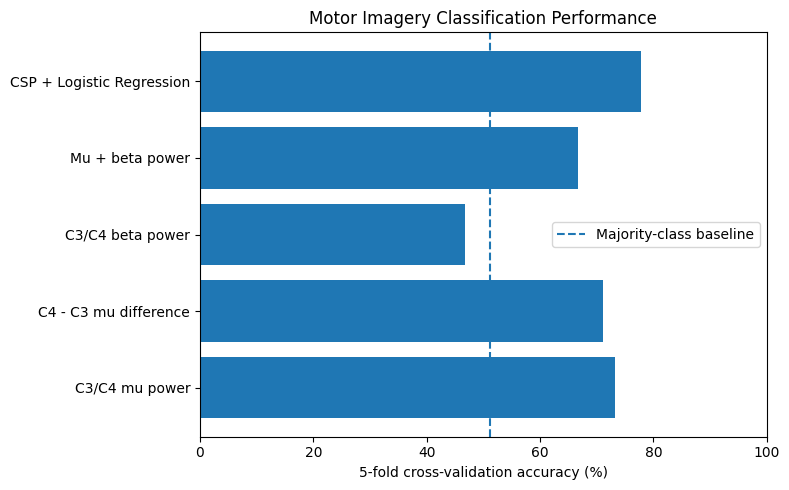

In [74]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    results["Method"],
    results["Mean CV Accuracy (%)"]
)

ax.axvline(
    23 / 45 * 100,
    linestyle="--",
    label="Majority-class baseline"
)

ax.set_xlabel("5-fold cross-validation accuracy (%)")
ax.set_title("Motor Imagery Classification Performance")
ax.set_xlim(0, 100)
ax.legend()

fig.tight_layout()

fig.savefig(
    "../figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

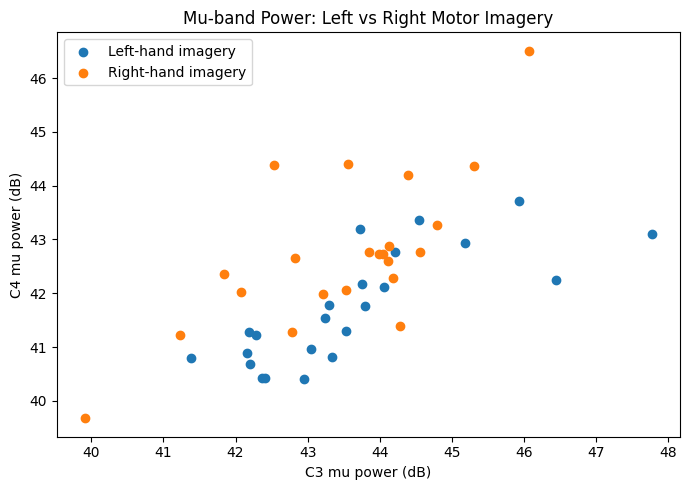

In [75]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    combined_mu_power_db[combined_y_binary == 0, 0],
    combined_mu_power_db[combined_y_binary == 0, 1],
    label="Left-hand imagery"
)

ax.scatter(
    combined_mu_power_db[combined_y_binary == 1, 0],
    combined_mu_power_db[combined_y_binary == 1, 1],
    label="Right-hand imagery"
)

ax.set_xlabel("C3 mu power (dB)")
ax.set_ylabel("C4 mu power (dB)")
ax.set_title("Mu-band Power: Left vs Right Motor Imagery")
ax.legend()

fig.tight_layout()

fig.savefig(
    "../figures/mu_power_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()